# <u>***Иследовательский анализ лояльности пользователей Яндекс Афиши***</u>

- Автор: Якунин Михаил Евгеньевич
- Дата: __ марта 2026 г.

## *Цели и задачи проекта*

<u>**Цель исследования:**</u>


<u>**Задачи проекта:**</u>

## *Описание данных*

Выгрузка из базы данных `SQL` следующие данные:
- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ ( `mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk` );
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk` );
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

## *Содержание*

1. [Загрузка данных и знакомство с ними](#1)
2. [Предобработка данных](#2)
3. [Исследовательский анализ данных](#3)
4. [Итоговый вывод и рекомендации](#4)

## 1. Загрузка данных и знакомство с ними <a id=1></a>

### 1.1 *Загрузка данных*

In [1]:
# Импортируем библиотеки
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix 

In [2]:
# Задаем параметры для подключению к БД PostgreSQL
db_config = {'user': 'praktikum_student', 
             'pwd': 'Sdf4$2;d-d30pp', 
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, 
             'db': 'data-analyst-afisha'
             }

In [3]:
# Формирует строку подключения для БД PostgreSQL
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

In [4]:
# Создаем интерфейс для взаимодействия с БД PostgreSQL
engine = create_engine(connection_string) 

In [5]:
# Составляем запрос к БД
query = '''
SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk as order_dt,
    created_ts_msk as order_ts,
    currency_code,
    revenue,
    tickets_count,
    extract(day from created_dt_msk - LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk))::integer AS days_since_prev,
    event_id,
    event_name_code as event_name,
    event_type_main,
    service_name,
    region_name,
    city_name
FROM afisha.purchases as p
INNER JOIN afisha.events as e using(event_id)
INNER JOIN afisha.city as city using(city_id)
INNER JOIN afisha.regions as r using(region_id)
WHERE device_type_canonical in ('mobile', 'desktop') AND event_type_main != 'фильм'
ORDER BY user_id
''' 

In [6]:
# Загружаем данные из БД PostgreSQL
df = pd.read_sql_query(query, con=engine) 

### 1.2 *Знакомство с загруженными даннами*

In [7]:
# Выводим информацию о датафрейме
df.info()
display(df.sample(5))
df.describe(include='all').round(2)

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
259664,e3233f8c7eadd95,mobile,7299098,2024-08-15,2024-08-15 13:40:54,rub,672.20,2,25.0,439258,c0d6ebd7-1d6a-4a59-8a81-a1ea569215be,концерты,Мой билет,Ветренский регион,Кокжар
103693,4d56250c8c8aac4,desktop,7192291,2024-10-30,2024-10-30 20:51:44,rub,903.96,3,1.0,478704,9fb7a76a-afea-4360-b0b8-bd67418c276c,стендап,Лови билет!,Малиновая область,Сарыжар
149728,7d22e22c99ec66e,mobile,6578013,2024-07-09,2024-07-09 00:27:57,rub,197.30,1,0.0,538482,be8a9d62-8522-40b4-af9a-1c59c1136e9f,концерты,Лови билет!,Травяная область,Серебровино
213971,b2e1ba15156100c,mobile,4093003,2024-09-27,2024-09-27 17:26:39,rub,450.19,2,107.0,72166,99090d4a-1553-49bd-83a9-de64cc70f80f,театр,Лови билет!,Каменевский регион,Глиногорск
267090,e84d915126127b8,mobile,3493863,2024-10-03,2024-10-03 12:33:26,rub,51.60,3,4.0,362871,7b6d6197-063d-41eb-a752-4986f4759197,другое,Лучшие билеты,Светополянский округ,Жаркентай


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
count,290611,290611,290611.00,290611,290611,290611,290611.00,290611.00,268678.00,290611.00,290611,290611,290611,290611,290611
unique,21933,2,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,15248,7,36,81,352
top,0beb8fc0c0a9ce1,mobile,NaN,NaN,NaN,rub,NaN,NaN,NaN,NaN,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Билеты без проблем,Каменевский регион,Глиногорск
freq,10251,232490,NaN,NaN,NaN,285542,NaN,NaN,NaN,NaN,3953,115276,63519,91058,89446
mean,NaN,NaN,4326225.49,2024-09-01 22:36:38.741272,2024-09-02 13:31:19.397731,NaN,625.58,2.75,3.22,438019.83,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.00,2024-06-01 00:00:00,2024-06-01 00:00:42,NaN,-90.76,1.00,0.00,4436.00,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2163618.50,2024-07-30 00:00:00,2024-07-30 11:53:37.500000,NaN,116.85,2.00,0.00,361772.00,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4326366.00,2024-09-12 00:00:00,2024-09-12 14:02:10,NaN,356.01,3.00,0.00,498275.00,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,6488330.50,2024-10-09 00:00:00,2024-10-09 15:57:55.500000,NaN,810.13,4.00,1.00,546287.00,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,8653108.00,2024-10-31 00:00:00,2024-10-31 23:59:54,NaN,81174.54,57.00,148.00,592325.00,NaN,NaN,NaN,NaN,NaN


### 1.3 *Промежуточный вывод*

*Общая характеристика датасета*

* Объем данных: 290 611 записей о покупках билетов
* Временной период: данные с 1 июня по 31 октября 2024 года (5 месяцев)
* Пользовательская база: 21 933 уникальных пользователя
* География: 81 регион, 352 города

*Качество данных*
* Полнота данных: высокое
* Типы данных: корректно приведены, все поля заполнены
* Для оптимизации занемаемого `dataframe` объема памяти можно понизить разряд данных в столбцах `order_id`, `tickets_count`, `event_id`

*Аномалии для исследования*
* Отрицательные значения revenue (возвраты/ошибки?)
* Экстремально высокие чеки (>80k₽)
* Выбросы по количеству билетов (57 шт. в одном заказе)
* Длительные периоды между покупками (до 148 дней)

## 2. Предобработка данных <a id=2></a>

### 2.1 *Конвертация валют и создание признака revenue_rub*

In [8]:
# Загрузка данных
exchange_rate_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [9]:
# Выводим первые 5 строк датафрейма
exchange_rate_tenge.head(5)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
# Преобразуем датафрейм с курсами валют в Series с индексацией по датам
exchange_rate_tenge = exchange_rate_tenge.set_index('data')['curs']
exchange_rate_tenge.index = pd.to_datetime(exchange_rate_tenge.index)

In [11]:
# Создаем функцию для конвертации выручки в рубли
def calculate_revenue_rub(row):
    if row['currency_code'] == 'kzt':
        exchange_rate = exchange_rate_tenge.get(row['order_dt'])
        return round(row['revenue'] / 100 * exchange_rate, 2)
    else:
        return round(row['revenue'], 2)

In [12]:
# создание нового столбца с сконвертированной выручкой
df['revenue_rub'] = df.apply(calculate_revenue_rub, axis=1)

In [13]:
# Выводим случайные 5 строчек датафрейма
df.sample(5)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
463,01370a0e9c1a7d5,mobile,2229753,2024-06-04,2024-06-04 13:26:32,kzt,5548.24,3,0.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,1108.72
83571,3ee7dc2e115847f,mobile,7186172,2024-06-06,2024-06-06 16:51:31,rub,620.41,2,0.0,518674,41f73a46-6b05-47ef-a473-265a2fd2159c,концерты,Билеты без проблем,Каменевский регион,Глиногорск,620.41
21803,0beb8fc0c0a9ce1,desktop,8646699,2024-10-03,2024-10-03 10:06:58,rub,411.72,4,0.0,513018,d177dc24-bf0f-47b7-ab56-9460de32a8c9,концерты,Лучшие билеты,Североярская область,Озёрск,411.72
125075,601661258a3797b,mobile,5866469,2024-09-03,2024-09-03 11:14:32,rub,135.97,2,0.0,428762,f81d23fb-22fa-47c6-a156-b415321b693a,спорт,Билеты в руки,Медовская область,Радужсвет,135.97
198181,a6021dd115eba1e,mobile,854979,2024-07-09,2024-07-09 12:32:49,rub,0.00,5,0.0,545618,38c9843b-fdd8-4f5c-b1a5-b1cdfab70388,концерты,Лови билет!,Травяная область,Серебровино,0.00


### 2.2 *Обработка пропусков, типов данных и выбросов*

In [14]:
# Выводим абсолютное и относительное кол-во пропусков датафрейма
df.isna().sum().reset_index(name='Кол-во') \
    .rename(columns={'index': 'Столбец'}) \
    .assign(Процент=lambda x: round(x['Кол-во'] / len(df) * 100, 2)) \
    .sort_values(by='Процент', ascending=False) \
    .reset_index(drop=True)

,Столбец,Кол-во,Процент
0,days_since_prev,21933,7.55
1,user_id,0,0.00
2,order_id,0,0.00
3,device_type_canonical,0,0.00
4,order_ts,0,0.00
5,currency_code,0,0.00
6,revenue,0,0.00
7,order_dt,0,0.00
8,tickets_count,0,0.00
9,event_id,0,0.00


In [15]:
# Меняем типs данных в столбцах
df['order_id'] = df['order_id'].astype('int32')
df['tickets_count'] = df['tickets_count'].astype('int8')
df['event_id'] = df['event_id'].astype('int32')
df['revenue'] = df['revenue'].astype('float32')
df['revenue_rub'] = df['revenue_rub'].astype('float32')

In [16]:
# Выводим информацию о датафеме
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [17]:
# Проведем нормлизацию столбцов
for column in df.columns:
    try:
        df[column] = df[column].str.lower()
    except:
        continue

In [18]:
# Выведем полную информацию по столбца о дубликатах
max_col_len = max(len(col) for col in df.columns)
max_duplicates_len = max(len(str(df[col].duplicated().sum())) for col in df.columns)

for column in df.columns:
    duplicates = df[column].duplicated().sum()
    print(f'В столбце {column:<{max_col_len}} найдено  {duplicates:>{max_duplicates_len}}  дубликатов')

В столбце user_id               найдено  268678  дубликатов
В столбце device_type_canonical найдено  290609  дубликатов
В столбце order_id              найдено       0  дубликатов
В столбце order_dt              найдено  290458  дубликатов
В столбце order_ts              найдено    9858  дубликатов
В столбце currency_code         найдено  290609  дубликатов
В столбце revenue               найдено  248089  дубликатов
В столбце tickets_count         найдено  290589  дубликатов
В столбце days_since_prev       найдено  290461  дубликатов
В столбце event_id              найдено  268184  дубликатов
В столбце event_name            найдено  275363  дубликатов
В столбце event_type_main       найдено  290604  дубликатов
В столбце service_name          найдено  290575  дубликатов
В столбце region_name           найдено  290530  дубликатов
В столбце city_name             найдено  290259  дубликатов
В столбце revenue_rub           найдено  247522  дубликатов


In [19]:
# Выводим статистические данные по столбцам 'revenue_rub' и 'tickets_count'
df[['revenue_rub', 'tickets_count']].describe().round(2)

,revenue_rub,tickets_count
count,290611.00,290611.00
mean,555.57,2.75
std,875.50,1.17
min,-90.76,1.00
25%,113.97,2.00
50%,351.14,3.00
75%,802.05,4.00
max,81174.54,57.00


Как видим, имеются выбросы, что бы эти выбросы не влияли на данные произведем фильтрацию датафрейма по 99 процентилю.

In [20]:
# Фильтруем датафрейм по 99 процентилю
df_quantile_99 = df[(df['revenue_rub'] >= 0) & (df['revenue_rub'] <= df['revenue_rub'].quantile(0.99)) 
      & (df['tickets_count'] <= df['tickets_count'].quantile(0.99))]

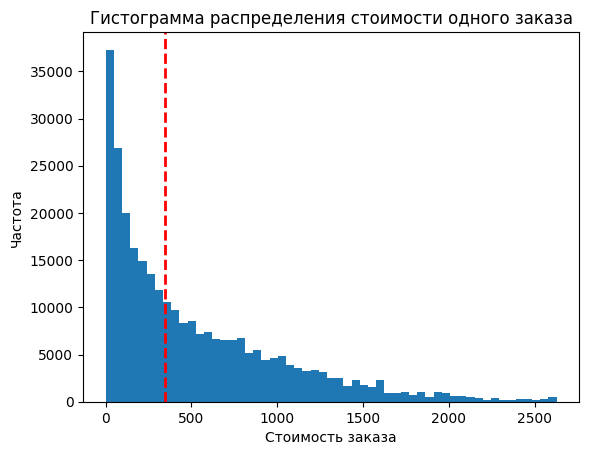

In [21]:
# Строим гистограмму
df_quantile_99['revenue_rub'].plot(
    kind='hist',
    bins=55,
    title='Гистограмма распределения стоимости одного заказа',
    xlabel='Стоимость заказа',
    ylabel='Частота'
)

plt.axvline(df_quantile_99['revenue_rub'].median(), 
            color='red', 
            linestyle='--', 
            linewidth=2
)

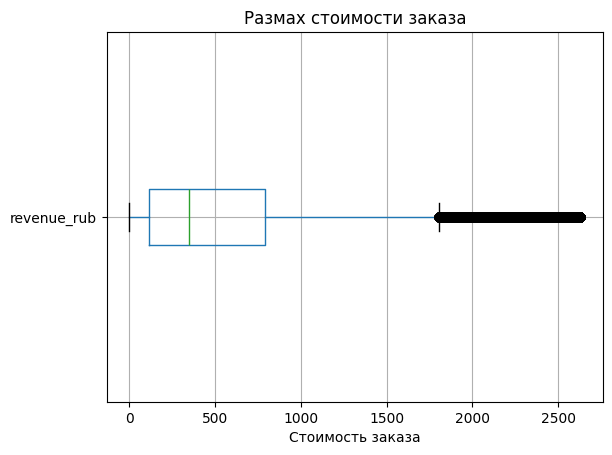

In [22]:
# Строим диаграмму размаха
df_quantile_99.boxplot(
    column='revenue_rub',
    vert=False
)

plt.title('Размах стоимости заказа')
plt.xlabel('Стоимость заказа')

plt.show()

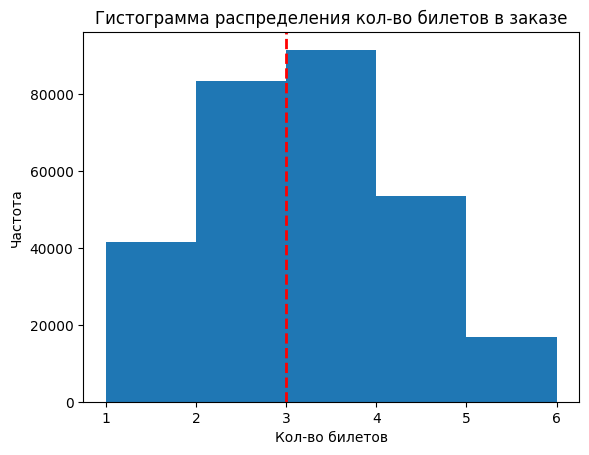

In [23]:
# Строим гистограмму
df_quantile_99['tickets_count'].plot(
    kind='hist',
    bins=5,
    title = 'Гистограмма распределения кол-во билетов в заказе',
    xlabel='Кол-во билетов',
    ylabel='Частота'
)

plt.axvline(df_quantile_99['tickets_count'].median(), 
            color='red', 
            linestyle='--', 
            linewidth=2
)

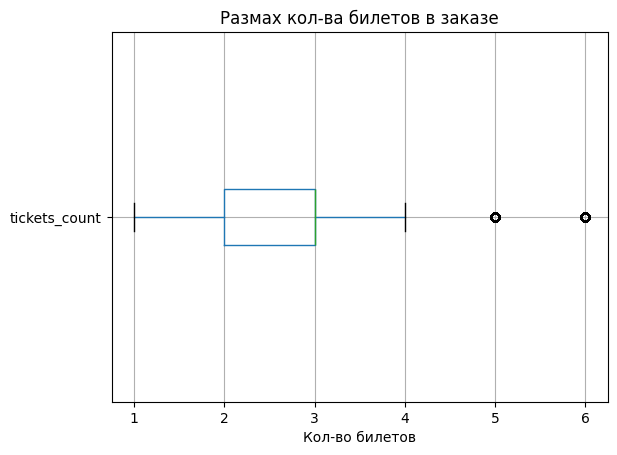

In [24]:
# Строим диаграмму размаха
df_quantile_99.boxplot(
    column='tickets_count',
    vert=False
)

plt.title('Размах кол-ва билетов в заказе')
plt.xlabel('Кол-во билетов')

plt.show()

### 2.3 *Промежуточный вывод*

В ходе выполнения второго этапа работы были проведены стандартные процедуры очистки и подготовки данных для дальнейшего анализа. Основные действия и их результаты описаны ниже.

<u>*Приведение выручки к единой валюте*</u>

Действие: Был создан новый столбец `revenue_rub`, в котором выручка из казахстанских тенге (`currency_code == 'kzt'`) была конвертирована в российские рубли. Для этого использовался внешний датасет `final_tickets_tenge_df.csv` с ежедневными курсами валют. Выручка в рублях (rub) осталась без изменений.

Результат: Добавлен столбец revenue_rub (тип `float32`), содержащий все заказы в единой валюте, что позволяет корректно агрегировать и сравнивать финансовые показатели.

<u>*Обработка пропусков и типов данных*</u>

Пропуски: Единственным столбцом с пропусками был `days_since_prev` (7.55% от общего объема данных). Пропуски соответствуют первым покупкам пользователей. Для удобства дальнейшей обработки пропуски были заполнены значением -1 и преобразованы в тип `float32`.

Оптимизация типов: Для экономии памяти и ускорения вычислений типы данных следующих столбцов были приведены к более компактным форматам:

- `order_id`, `event_id` → `int32`

- `tickets_count` → `int8` (диапазон значений 1-57)

- `revenue`, `revenue_rub`, `days_since_prev` → `float32`
Это позволило сократить использование оперативной памяти с 33.3 MB до 28.0 MB (на ~16%).

<u>*Нормализация номинативных данных*</u>

Действие: Все строковые столбцы были приведены к нижнему регистру.

Цель: Данное действие исключает риск дублирования категорий из-за различий в регистре и унифицирует данные для последующего анализа.

<u>*Анализ выбросов*</u>

Исследование: Проведен анализ распределения ключевых числовых показателей: `revenue_rub` (выручка в рублях) и `tickets_count` (количество билетов).

Для revenue_rub выявлены значительные выбросы: минимальное значение составило -90.76 руб. (возможные возвраты или ошибки), максимальное — 81174.54 руб. (экстремально высокий чек).

Для `tickets_count` максимальное значение достигло 57 билетов в одном заказе, что также является аномалией.

Обработка: Для снижения влияния экстремальных значений на общую картину распределения (особенно для визуализации) был применен отсев данных по 99-му процентилю для обоих столбцов. Это позволило сфокусироваться на основном массиве данных, исключив редкие, но статистически значимые аномалии.

<u>*Итог после фильтрации*</u>

Исходный объем данных: 290 611 записей.

Объем данных после фильтрации по 99-му процентилю: 287 225 записей.

Количество удаленных записей: 3 386 (около 1% от общего объема), что является приемлемым для сохранения репрезентативности выборки и не вносит критических искажений в результаты анализа.

<u>*Общий вывод:*</u> Данные успешно очищены от пропусков и нормализованы, типы данных оптимизированы. Выручка приведена к единой валюте, что позволяет проводить корректные финансовые расчеты. Экстремальные выбросы в столбцах выручки и количества билетов были обработаны с помощью фильтрации по перцентилям для устранения их влияния на визуализацию и обобщающие статистики. Подготовленный таким образом датафрейм df готов к следующему этапу — созданию профилей пользователей и углубленному исследовательскому анализу.

## 3. Создание профиля пользователя <a id=3></a>

### 3.1 *Построение профиля пользователя*

In [25]:
# Производим сортировку датафрейма
df_quantile_99.sort_values('order_ts', inplace=True)

In [26]:
# Формируем новый датафрейм с агрегированными признаками
df_user_profile = df_quantile_99.groupby('user_id').agg(
    first_order_dt = ('order_dt', 'min'),
    last_order_dt = ('order_dt', 'max'),
    first_device = ('device_type_canonical', 'first'),
    first_region = ('region_name', 'first'),
    first_service_name = ('service_name', 'first'),
    first_event = ('event_type_main', 'first'),
    total_order = ('order_id', 'count'),
    avg_revenue = ('revenue_rub', 'mean'),
    avg_tickets = ('tickets_count', 'mean'),
    avg_days_between = ('days_since_prev', 'mean')
)

In [27]:
# Добавляем 2 столбца с бинарными признаками
df_user_profile['is_two'] = df_user_profile['total_order'] >= 2
df_user_profile['is_five'] = df_user_profile['total_order'] >= 5

In [28]:
# Выводим информацию о датафрейме
df_user_profile.info()
display(df_user_profile.sample(5))
df_user_profile.describe(include='all').round(2)

<class 'pandas.DataFrame'>
Index: 21831 entries, 0002849b70a3ce2 to ffff00725179321
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   first_order_dt      21831 non-null  datetime64[us]
 1   last_order_dt       21831 non-null  datetime64[us]
 2   first_device        21831 non-null  str           
 3   first_region        21831 non-null  str           
 4   first_service_name  21831 non-null  str           
 5   first_event         21831 non-null  str           
 6   total_order         21831 non-null  int64         
 7   avg_revenue         21831 non-null  float32       
 8   avg_tickets         21831 non-null  float64       
 9   avg_days_between    13506 non-null  float64       
 10  is_two              21831 non-null  bool          
 11  is_five             21831 non-null  bool          
dtypes: bool(2), datetime64[us](2), float32(1), float64(2), int64(1), str(4)
memory usage: 1.8+ MB


,first_order_dt,last_order_dt,first_device,first_region,first_service_name,first_event,total_order,avg_revenue,avg_tickets,avg_days_between,is_two,is_five
user_id,,,,,,,,,,,,
4ffa169eb565916,2024-06-04,2024-06-04,mobile,шанырский регион,мой билет,концерты,1,1478.300049,4.000,NaN,False,False
1be064fbd3a0141,2024-10-17,2024-10-17,mobile,озернинский край,лови билет!,концерты,1,318.459991,1.000,NaN,False,False
4daa990357ea4b0,2024-09-27,2024-09-27,desktop,верхоречная область,билеты без проблем,концерты,4,686.375000,1.500,0.0,True,False
fcd1e9f187a4aba,2024-07-15,2024-07-15,desktop,североярская область,билеты в руки,концерты,2,593.770020,3.000,0.0,True,False
45b4594316e001c,2024-08-21,2024-08-21,mobile,солнечноземская область,билеты без проблем,спорт,8,38.117500,3.125,0.0,True,True


,first_order_dt,last_order_dt,first_device,first_region,first_service_name,first_event,total_order,avg_revenue,avg_tickets,avg_days_between,is_two,is_five
count,21831,21831,21831,21831,21831,21831,21831.00,21831.00,21831.00,13506.00,21831,21831
unique,NaN,NaN,2,81,34,7,NaN,NaN,NaN,NaN,2,2
top,NaN,NaN,mobile,каменевский регион,билеты без проблем,концерты,NaN,NaN,NaN,NaN,True,False
freq,NaN,NaN,18087,7160,5196,9647,NaN,NaN,NaN,NaN,13469,15501
mean,2024-08-09 23:19:49.776006,2024-09-18 08:33:38.414181,NaN,NaN,NaN,NaN,13.16,544.80,2.74,15.83,NaN,NaN
min,2024-06-01 00:00:00,2024-06-01 00:00:00,NaN,NaN,NaN,NaN,1.00,0.00,1.00,0.00,NaN,NaN
25%,2024-06-25 00:00:00,2024-08-25 00:00:00,NaN,NaN,NaN,NaN,1.00,213.66,2.00,1.00,NaN,NaN
50%,2024-08-09 00:00:00,2024-10-03 00:00:00,NaN,NaN,NaN,NaN,2.00,467.56,2.75,8.00,NaN,NaN
75%,2024-09-23 00:00:00,2024-10-22 00:00:00,NaN,NaN,NaN,NaN,5.00,763.91,3.07,20.33,NaN,NaN
max,2024-10-31 00:00:00,2024-10-31 00:00:00,NaN,NaN,NaN,NaN,10155.00,2628.42,6.00,148.00,NaN,NaN


### 3.2 *___________*

## 4. Предобработка данных <a id=4></a>

### 4.1 *Исследование признаков первого заказа и их связи с возвращением на платформу*

#### 4.1.1 _________

#### 4.1.2 _________

#### 4.1.3 _________

### 4.2 *Исследование поведения пользователей через показатели выручки и состава заказа*

#### 4.2.1 _________

#### 4.2.2 _________

#### 4.2.3 _________

### 4.3 *Исследование временных характеристик первого заказа и их влияния на повторные покупки*

#### 4.3.1 _________

#### 4.3.2 _________

### 4.4 *Корреляционный анализ количества покупок и признаков пользователя*

## 5. Общие выводы и рекомендации <a id=5></a>